<a href="https://colab.research.google.com/github/mohiuddinarafat17/CMAPSSData/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
!pip install shap xgboost tensorflow scikit-learn pandas numpy matplotlib seaborn -q

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import xgboost as xgb
import shap

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    GRU,
    Dense,
    Dropout,
    Conv1D,
    MaxPooling1D,
    Bidirectional
)

from tensorflow.keras.callbacks import EarlyStopping

In [38]:
from google.colab import files

uploaded = files.upload()

Saving CMAPSSData.zip to CMAPSSData (1).zip


In [39]:
train = pd.read_csv(
    "train_FD002.txt",
    sep=r"\s+",
    header=None
)

test = pd.read_csv(
    "test_FD002.txt",
    sep=r"\s+",
    header=None
)

RUL = pd.read_csv(
    "RUL_FD002.txt",
    header=None
)

print(train.shape)
print(test.shape)

(53759, 26)
(33991, 26)


In [40]:
train.dropna(axis=1, how='all', inplace=True)
test.dropna(axis=1, how='all', inplace=True)

print(train.shape)
print(test.shape)

(53759, 26)
(33991, 26)


In [41]:
column_names = (

    ['engine_id', 'cycle']

    +

    [f'op_setting_{i}' for i in range(1,4)]

    +

    [f'sensor_{i}' for i in range(1,22)]

)

train.columns = column_names
test.columns = column_names

train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


In [42]:
max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()

max_cycle.columns = ['engine_id', 'max_cycle']

train = train.merge(max_cycle, on='engine_id')

train['RUL'] = train['max_cycle'] - train['cycle']

train.drop('max_cycle', axis=1, inplace=True)

train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071,148
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,147
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,146
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,145
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,144


In [43]:
train['RUL'] = train['RUL'].clip(upper=125)

In [44]:
features = [

    c for c in train.columns

    if c not in ['engine_id', 'cycle', 'RUL']

]

print(features)

['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [45]:
scaler = MinMaxScaler()

train[features] = scaler.fit_transform(train[features])

test[features] = scaler.transform(test[features])

In [46]:
engines = train['engine_id'].unique()

train_engines, val_engines = train_test_split(

    engines,

    test_size=0.2,

    random_state=42

)

train_df = train[
    train['engine_id'].isin(train_engines)
]

val_df = train[
    train['engine_id'].isin(val_engines)
]

print(train_df.shape)
print(val_df.shape)

(43464, 27)
(10295, 27)


In [47]:
X_train = train_df[features]
y_train = train_df['RUL']

X_val = val_df[features]
y_val = val_df['RUL']

In [48]:
rf = RandomForestRegressor(

    n_estimators=300,

    max_depth=20,

    random_state=42,

    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)

In [49]:
xgb_model = xgb.XGBRegressor(

    n_estimators=500,

    learning_rate=0.03,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='reg:squarederror',

    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)

In [50]:
gb = GradientBoostingRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_val)

In [51]:
SEQ_LEN = 30

def create_engine_sequences(df, seq_len, features):

    X_seq = []
    y_seq = []

    for engine_id in df['engine_id'].unique():

        engine_data = df[df['engine_id'] == engine_id]

        data = engine_data[features].values
        target = engine_data['RUL'].values

        for i in range(len(data) - seq_len):

            X_seq.append(data[i:i+seq_len])

            y_seq.append(target[i+seq_len])

    return np.array(X_seq), np.array(y_seq)

In [52]:
X_train_seq, y_train_seq = create_engine_sequences(

    train_df,

    SEQ_LEN,

    features
)

X_val_seq, y_val_seq = create_engine_sequences(

    val_df,

    SEQ_LEN,

    features
)

print(X_train_seq.shape)
print(X_val_seq.shape)

(37224, 30, 24)
(8735, 30, 24)


In [53]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [54]:
lstm = Sequential([

    LSTM(
        128,
        return_sequences=True,
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    ),

    Dropout(0.3),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1)

])

lstm.compile(

    optimizer='adam',

    loss='mse'
)

history_lstm = lstm.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(X_val_seq, y_val_seq),

    epochs=50,

    batch_size=256,

    callbacks=[early_stop],

    verbose=1
)

lstm_pred = lstm.predict(X_val_seq).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - loss: 5680.3032 - val_loss: 2570.2517
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 40s 276ms/step - loss: 1968.1342 - val_loss: 1736.1260
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 42s 283ms/step - loss: 1796.8774 - val_loss: 1737.8583
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 41s 280ms/step - loss: 1794.0911 - val_loss: 1737.9938
Epoch 5/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 41s 277ms/step - loss: 1789.6611 - val_loss: 1735.1777
Epoch 6/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 40s 275ms/step - loss: 1786.6359 - val_loss: 1736.0654
Epoch 7/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 40s 277ms/step - loss: 1782.9923 - val_loss: 1739.0077
Epoch 8/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 42s 281ms/step - loss: 1796.5040 - val_loss: 1735.8098
Epoch 9/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 41s 278ms/step - loss: 1789.9589 - val_loss: 1740.3320
Epoch 10/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 53s 364ms/step - loss: 1791.6620 - val_loss: 1733.2454
Epoch 11/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 66s 451m

In [55]:
gru = Sequential([

    GRU(
        128,
        return_sequences=True,
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    ),

    Dropout(0.3),

    GRU(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1)

])

gru.compile(

    optimizer='adam',

    loss='mse'
)

history_gru = gru.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(X_val_seq, y_val_seq),

    epochs=50,

    batch_size=256,

    callbacks=[early_stop],

    verbose=1
)

gru_pred = gru.predict(X_val_seq).flatten()

Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 47s 297ms/step - loss: 5067.3535 - val_loss: 2278.9990
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 44s 299ms/step - loss: 1911.0511 - val_loss: 1734.1968
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 44s 301ms/step - loss: 1790.1064 - val_loss: 1736.5360
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 43s 295ms/step - loss: 1790.0669 - val_loss: 1735.4423
Epoch 5/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 43s 297ms/step - loss: 1787.6045 - val_loss: 1741.8403
273/273 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [56]:
cnn_lstm = Sequential([

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    ),

    MaxPooling1D(pool_size=2),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1)

])

cnn_lstm.compile(

    optimizer='adam',

    loss='mse'
)

history_cnn = cnn_lstm.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(X_val_seq, y_val_seq),

    epochs=50,

    batch_size=256,

    callbacks=[early_stop],

    verbose=1
)

cnn_pred = cnn_lstm.predict(X_val_seq).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 5138.6377 - val_loss: 2002.9550
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 1832.2777 - val_loss: 1739.4167
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 1795.6498 - val_loss: 1735.1052
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - loss: 1789.7611 - val_loss: 1732.4718
Epoch 5/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 1795.7906 - val_loss: 1735.3619
Epoch 6/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - loss: 1798.6888 - val_loss: 1735.7343
Epoch 7/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - loss: 1790.4492 - val_loss: 1729.3035
Epoch 8/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 1775.0746 - val_loss: 1679.8356
Epoch 9/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - loss: 1572.6324 - val_loss: 1252.1941
Epoch 10/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 998.8916 - val_loss: 873.0250
Epoch 11/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 864.67

In [57]:
results = {}

def evaluate(name, y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    results[name] = rmse

    print("\n", name)

    print("RMSE:", rmse)

    print("MAE:", mae)

    print("R2:", r2)

In [58]:
evaluate("Random Forest", y_val, rf_pred)

evaluate("XGBoost", y_val, xgb_pred)

evaluate("Gradient Boosting", y_val, gb_pred)

evaluate("LSTM", y_val_seq, lstm_pred)

evaluate("GRU", y_val_seq, gru_pred)

evaluate("CNN-LSTM", y_val_seq, cnn_pred)


 Random Forest
RMSE: 19.901864993265995
MAE: 14.586559359037846
R2: 0.7731213325324834

 XGBoost
RMSE: 19.708312257052462
MAE: 14.29166316986084
R2: 0.777512788772583

 Gradient Boosting
RMSE: 19.925638926566638
MAE: 14.644009408322209
R2: 0.7725789693004779

 LSTM
RMSE: 41.63226200025423
MAE: 36.78749465942383
R2: -0.0013600587844848633

 GRU
RMSE: 47.73885770686444
MAE: 41.607826232910156
R2: -0.3166619539260864

 CNN-LSTM
RMSE: 21.7432366740661
MAE: 17.137283325195312
R2: 0.726864218711853


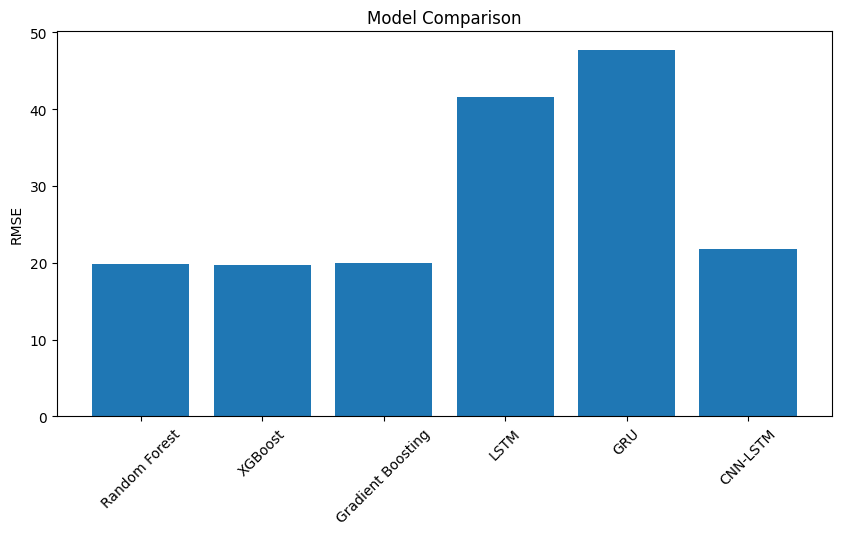

In [59]:
plt.figure(figsize=(10,5))

plt.bar(

    results.keys(),

    results.values()
)

plt.xticks(rotation=45)

plt.ylabel("RMSE")

plt.title("Model Comparison")

plt.show()

In [60]:
best_model = min(results, key=results.get)

print("Best Model:", best_model)

Best Model: XGBoost


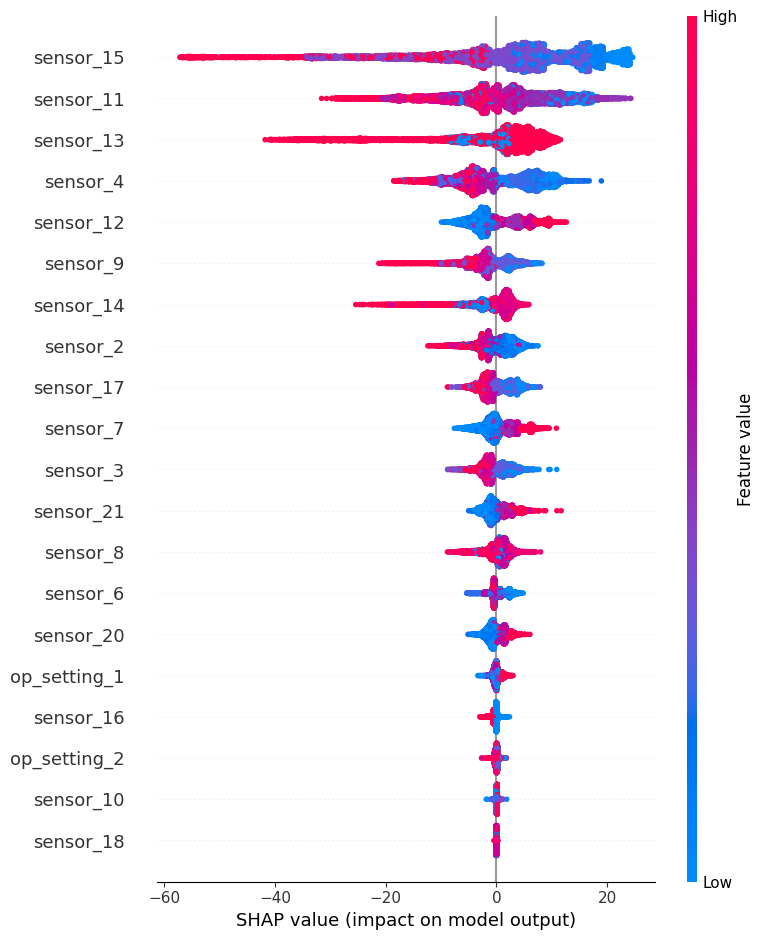

In [61]:
explainer = shap.Explainer(xgb_model)

shap_values = explainer(X_val)

shap.summary_plot(

    shap_values,

    X_val
)

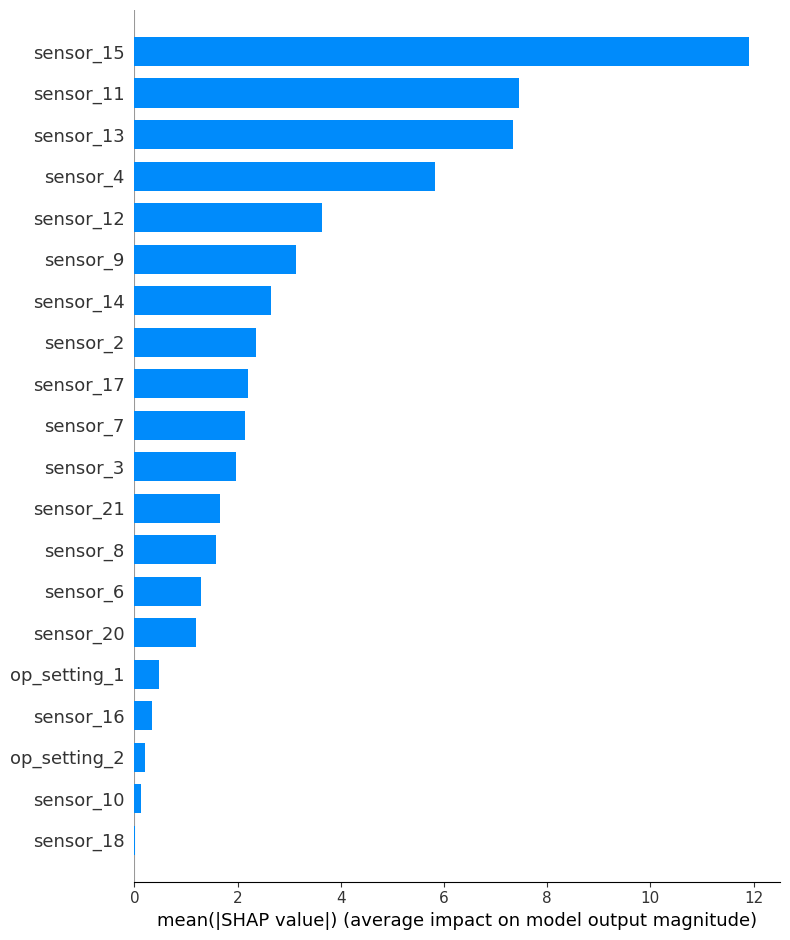

In [62]:
shap.summary_plot(

    shap_values,

    X_val,

    plot_type="bar"
)

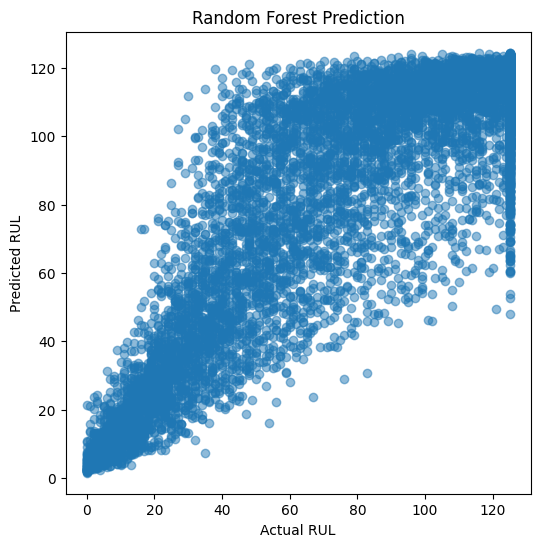

In [63]:
plt.figure(figsize=(6,6))

plt.scatter(

    y_val,

    rf_pred,

    alpha=0.5
)

plt.xlabel("Actual RUL")

plt.ylabel("Predicted RUL")

plt.title("Random Forest Prediction")

plt.show()

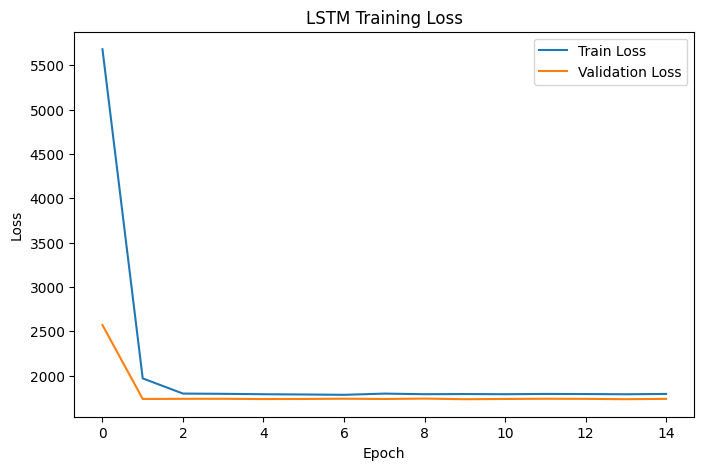

In [64]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['loss'])

plt.plot(history_lstm.history['val_loss'])

plt.legend(['Train Loss', 'Validation Loss'])

plt.title("LSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [65]:
print("======================================")

print("SHAP-Guided Deep Learning Framework")

print("Dataset: NASA FD002")

print("Models Used:")
print("1. Random Forest")
print("2. XGBoost")
print("3. Gradient Boosting")
print("4. LSTM")
print("5. GRU")
print("6. CNN-LSTM")

print("Best Model:", best_model)

print("======================================")

SHAP-Guided Deep Learning Framework
Dataset: NASA FD002
Models Used:
1. Random Forest
2. XGBoost
3. Gradient Boosting
4. LSTM
5. GRU
6. CNN-LSTM
Best Model: XGBoost
